# 🏦 FinanceRAG: Hybrid Retrieval Pipeline

> **Competition:** [ICAIF-24 Finance RAG Challenge](https://www.kaggle.com/competitions/icaif-24-finance-rag-challenge)

## 🎯 Approach Overview

This notebook implements a **multi-stage retrieval pipeline** optimized for financial document retrieval across 7 diverse datasets spanning 10-K reports, earnings calls, and financial disclosures.

### Pipeline Architecture
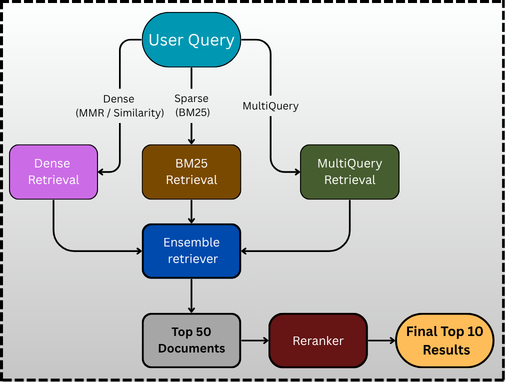

### Key Design Decisions

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Passage Embedding | `BAAI/bge-large-en-v1.5` | Best general retrieval quality |
| Tabular Embedding | `FinLang/finance-embeddings-investopedia` | Finance-domain finetuned |
| Sparse Retrieval | BM25 | Catches exact ticker/figure matches |
| Fusion | RRF (k=60) | Parameter-free, robust across datasets |
| Reranker | `BAAI/bge-reranker-base` | Cross-encoder precision at 278M params |
| Chunk Size | 512 (passage) / 1024 (tabular) | Optimized per dataset type |

In [1]:
!pip install -q langchain langchain-community langchain-huggingface
!pip install -q langchain-chroma langchain-text-splitters
!pip install -q rank_bm25 sentence-transformers
!pip install -q langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
gcsfs 2025.3.0 req

In [2]:
pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 8.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
import langchain
import langchain_core

print(f"LangChain Version: {langchain.__version__}")
print(f"LangChain Core Version: {langchain_core.__version__}")

LangChain Version: 1.2.10
LangChain Core Version: 1.3.2


In [4]:
!pip install -q nltk  # BM25Retriever dependency

# Run this once after install
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

# Verify correct module locations
from langchain_classic.retrievers import EnsembleRetriever
print("✅ EnsembleRetriever:", EnsembleRetriever.__module__)

from langchain_classic.retrievers.multi_query import MultiQueryRetriever
print("✅ MultiQueryRetriever:", MultiQueryRetriever.__module__)

from langchain_community.retrievers import BM25Retriever
print("✅ BM25Retriever:", BM25Retriever.__module__)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✅ EnsembleRetriever: langchain_classic.retrievers.ensemble
✅ MultiQueryRetriever: langchain_classic.retrievers.multi_query
✅ BM25Retriever: langchain_community.retrievers.bm25


## 📚 Imports & Setup

In [5]:
import json
import os
import csv
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch

# LangChain Core
from langchain_core.documents import Document

# # LangChain Retrievers — correct paths for langchain >= 0.2
# from langchain.retrievers import EnsembleRetriever          # still here
# from langchain.retrievers.multi_query import MultiQueryRetriever   # still here
# from langchain_community.retrievers import BM25Retriever    # in community

# LangChain Splitters + Embeddings + VectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# LLM for MultiQuery
from langchain_groq import ChatGroq

# Reranker
from sentence_transformers import CrossEncoder
from rank_bm25 import BM25Okapi

# Evaluation
from sklearn.metrics import ndcg_score as sklearn_ndcg

from dotenv import load_dotenv
load_dotenv()

print("✅ All imports loaded successfully")

✅ All imports loaded successfully


In [6]:
import torch

BASE_PATH = "/kaggle/input/competitions/icaif-24-finance-rag-challenge"

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
print(f"🚀 Using device: {device}")

🚀 Using device: cuda


## 🗂️ Dataset Configuration

We configure each dataset with a tailored chunking strategy based on its document type:

- **Passage datasets** (FinDER, FinanceBench, FinQABench): 512-token chunks with sentence-boundary separators. These contain long narrative disclosures where full sentences carry meaning.
- **Tabular datasets** (FinQA, TATQA, ConvFinQA, MultiHiertt): 1024-token chunks with pipe `|` separators to preserve table row integrity. Larger chunks ensure a full table row + header stays together.

In [7]:
# fmt: (corpus_file, query_file, qrels_file, chunk_size, chunk_overlap, dataset_type)
DATASETS = {
    # ── Passage Retrieval ──────────────────────────────────────
    "finder": (
        "finder_corpus.jsonl/corpus.jsonl",
        "finder_queries.jsonl/queries.jsonl",
        "FinDER_qrels.tsv",
        512, 64, "passage"
    ),
    "financebench": (
        "financebench_corpus.jsonl/corpus.jsonl",
        "financebench_queries.jsonl/queries.jsonl",
        "FinanceBench_qrels.tsv",
        512, 64, "passage"
    ),
    "finqabench": (
        "finqabench_corpus.jsonl/corpus.jsonl",
        "finqabench_queries.jsonl/queries.jsonl",
        "FinQABench_qrels.tsv",
        1024, 128, "passage"
    ),
    # ── Tabular + Text ─────────────────────────────────────────
    "finqa": (
        "finqa_corpus.jsonl/corpus.jsonl",
        "finqa_queries.jsonl/queries.jsonl",
        "FinQA_qrels.tsv",
        1024, 128, "tabular"
    ),
    "tatqa": (
        "tatqa_corpus.jsonl/corpus.jsonl",
        "tatqa_queries.jsonl/queries.jsonl",
        "TATQA_qrels.tsv",
        1024, 128, "tabular"
    ),
    "convfinqa": (
        "convfinqa_corpus.jsonl/corpus.jsonl",
        "convfinqa_queries.jsonl/queries.jsonl",
        "ConvFinQA_qrels.tsv",
        1024, 128, "tabular"
    ),
    "multiheirtt": (
        "multiheirtt_corpus.jsonl/corpus.jsonl",
        "multiheirtt_queries.jsonl/queries.jsonl",
        "MultiHeirtt_qrels.tsv",
        1024, 128, "tabular"
    ),
}

print(f"✅ {len(DATASETS)} datasets configured")

✅ 7 datasets configured


## 🔧 Data Loading Helpers

In [8]:
def load_jsonl(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]

def load_qrels(path):
    df = pd.read_csv(path, sep="\t")
    return df.groupby("query_id").apply(
        lambda x: dict(zip(x["corpus_id"], x["score"])),
        include_groups=False
    ).to_dict()

def corpus_to_documents(corpus):
    """Convert raw corpus list to LangChain Document objects."""
    docs = []
    for item in corpus:
        text = (item.get("title", "") + " " + item["text"]).strip()
        docs.append(Document(
            page_content=text,
            metadata={"id": item["_id"]}
        ))
    return docs

print("✅ Data loaders ready")

✅ Data loaders ready


## ✂️ Dataset-Aware Document Chunker

Different financial document types require different chunking strategies:

- **Passage docs**: Split on sentence boundaries (`. `) — preserves semantic units in narrative text
- **Tabular docs**: Split on pipe `|` characters — keeps table rows intact for numerical reasoning

In [9]:
def split_documents(corpus, chunk_size=512, chunk_overlap=64, dataset_type="passage"):
    """
    Split corpus into chunks with dataset-aware separators.
    Returns:
        documents   : List[str]  — chunk texts
        ids         : List[str]  — unique Chroma IDs
        original_ids: List[str]  — original corpus doc IDs (aligned with documents)
        lc_docs     : List[Document] — LangChain Documents for BM25Retriever
    """
    separators = (
        ["\n\n", "\n", "|", " ", ""] if dataset_type == "tabular"
        else ["\n\n", "\n", ". ", " ", ""]
    )

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=separators
    )

    documents    = []
    ids          = []
    original_ids = []
    lc_docs      = []

    for doc_idx, doc in enumerate(corpus):
        text   = (doc.get("title", "") + " " + doc["text"]).strip()
        chunks = splitter.split_text(text)

        for chunk_idx, chunk in enumerate(chunks):
            chroma_id = f"{doc_idx}_{doc['_id']}_chunk{chunk_idx}"
            documents.append(chunk)
            ids.append(chroma_id)
            original_ids.append(doc["_id"])
            lc_docs.append(Document(
                page_content=chunk,
                metadata={"id": doc["_id"]}
            ))

    print(f"  📄 Original docs : {len(corpus)}")
    print(f"  🧩 Total chunks  : {len(documents)}")
    return documents, ids, original_ids, lc_docs

print("✅ Chunker ready")

✅ Chunker ready


## 🧠 Embedding Models

We use **domain-specific embedding models**:  `FinLang/finance-embeddings-investopedia`

In [10]:
print("⏳ Loading embedding models...")
torch.cuda.empty_cache()

embedding_passage = HuggingFaceEmbeddings(
    model_name="FinLang/finance-embeddings-investopedia",
    model_kwargs={"device": device},
    encode_kwargs={"batch_size": 32, "normalize_embeddings": True}
)
torch.cuda.empty_cache()

embedding_tabular = HuggingFaceEmbeddings(
    model_name="FinLang/finance-embeddings-investopedia",
    model_kwargs={"device": device},
    encode_kwargs={"batch_size": 32, "normalize_embeddings": True}
)
torch.cuda.empty_cache()

def get_embedding_model(dataset_type):
    return embedding_passage if dataset_type == "passage" else embedding_tabular

print("✅ Embedding models loaded")

⏳ Loading embedding models...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/172 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Embedding models loaded


## 🎯 Reranker

`BAAI/bge-reranker-base` is a **cross-encoder** that scores each (query, document) pair jointly — unlike bi-encoders that embed them separately. This joint scoring is significantly more accurate but slower, so we apply it only to the top-50 candidates from RRF fusion.

- **Input**: Raw query + document text pair  
- **Output**: Scalar relevance score

In [11]:
reranker = CrossEncoder(
    "BAAI/bge-reranker-v2-m3",
    device=device,
    max_length=512
)
print("✅ Reranker loaded  (BAAI/bge-reranker-base)")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

✅ Reranker loaded  (BAAI/bge-reranker-base)


## 🤖 LLM for Multi-Query Retrieval

`MultiQueryRetriever` uses an LLM to automatically generate **3 alternative phrasings** of each query. This expands recall by catching documents that match one phrasing but not another — especially useful for financial jargon where the same concept has multiple valid expressions (e.g., *"net income"* vs *"profit after tax"* vs *"earnings"*).

We use **Groq's meta-llama/llama-4-scout-17b-16e-instruct** — fast, free-tier available, and sufficient for query reformulation.

In [12]:
# Groq offers a free tier — set GROQ_API_KEY in Kaggle Secrets
# If unavailable, MultiQuery falls back gracefully (see pipeline cell)
import os
from kaggle_secrets import UserSecretsClient

try:
    os.environ["GROQ_API_KEY"] = UserSecretsClient().get_secret("GROQ_API_KEY")
    os.environ["GOOGLE_API_KEY"] = UserSecretsClient().get_secret("GOOGLE_API_KEY")
    print("✅ Secrets successfully loaded to environment.")
except Exception as e:
    print(f"⚠️ Could not load secrets: {e}")

GROQ_API_KEY = os.environ.get("GROQ_API_KEY", None)

if GROQ_API_KEY:
    llm = ChatGroq(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        temperature=0,
        max_tokens=256,
    )
    USE_MULTIQUERY = True
    print("✅ LLM loaded")
else:
    llm = None
    USE_MULTIQUERY = False
    print("⚠️  GROQ_API_KEY not found — MultiQuery DISABLED (pipeline continues without it)")

⚠️ Could not load secrets: Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 116881957 and label GROQ_API_KEY.'], 'error': {'code': 5}, 'wasSuccessful': False}.
⚠️  GROQ_API_KEY not found — MultiQuery DISABLED (pipeline continues without it)


## 🗄️ Vector Store Builder

ChromaDB persists embeddings to disk so they survive across notebook sessions. We skip rebuilding if the directory already exists - this saves ~30 minutes on large datasets like MultiHiertt.

In [13]:
def build_vectorstore(documents, ids, original_ids, persist_dir, embedding_model):
    vectorstore = Chroma(
        persist_directory=persist_dir,
        embedding_function=embedding_model
    )

    batch_size = 64
    for i in tqdm(range(0, len(documents), batch_size), desc="  Indexing"):
        vectorstore.add_texts(
            texts=documents[i:i+batch_size],
            metadatas=[{"id": oid} for oid in original_ids[i:i+batch_size]],
            ids=ids[i:i+batch_size]
        )

    return vectorstore

print("✅ Vector store builder ready")

✅ Vector store builder ready


## 🔍 Retrieval Pipeline

### Stage 1 - Three Parallel Retrievers



### Stage 2 - Reciprocal Rank Fusion (RRF)

RRF score for document $d$:

$$\text{RRF}(d) = \sum_{r \in \text{retrievers}} \frac{1}{k + \text{rank}_r(d)}$$

where $k=60$ is the standard constant. RRF is **parameter-free** — no alpha tuning needed — and consistently outperforms weighted linear combination.

### Stage 3 - Cross-Encoder Reranking

The reranker scores each (query, best-chunk-of-doc) pair jointly using full attention across both sequences, producing a much more accurate relevance estimate than embedding cosine similarity.


In [14]:
# ── Retrieval Functions ────────────────────────────────────────

def build_ensemble_retriever(vectorstore, bm25_retriever_cached, ds_type,
                              fetch_k=75, use_multiquery=False, llm=None):
    search_type = "mmr" if ds_type == "passage" else "similarity"

    if search_type == "mmr":
        dense_retriever = vectorstore.as_retriever(
            search_type="mmr",
            search_kwargs={"k": fetch_k, "fetch_k": fetch_k * 3, "lambda_mult": 0.7}
        )
    else:
        dense_retriever = vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={"k": fetch_k}
        )

    retrievers = [dense_retriever, bm25_retriever_cached]
    weights    = [0.5, 0.5] if ds_type == "passage" else [0.4, 0.6]

    if use_multiquery and llm is not None:
        multi_retriever = MultiQueryRetriever.from_llm(
            retriever=vectorstore.as_retriever(
                search_type="similarity",
                search_kwargs={"k": 20}
            ),
            llm=llm,
            include_original=True
        )
        retrievers.append(multi_retriever)
        total  = sum(weights) + 0.4
        weights = [w / total for w in weights] + [0.4 / total]

    return EnsembleRetriever(
        retrievers=retrievers,
        weights=weights,
        c=60
    )


def retrieve_and_rerank(ensemble, bm25_okapi, documents, original_ids,
                        query, k=10, rerank_top_n=30):
    """
    Per-query retrieval.
    bm25_okapi   : pre-built BM25Okapi index (cached outside loop)
    rerank_top_n : how many candidates to pass to cross-encoder
                   smaller = faster, larger = more accurate
    """
    # ── Stage 1: EnsembleRetriever (RRF fusion) ────────────────
    fused_docs = ensemble.invoke(query)

    if not fused_docs:
        return []

    # Deduplicate by original corpus ID, cap at rerank_top_n
    seen          = {}
    candidate_ids = []
    for doc in fused_docs:
        orig_id = doc.metadata["id"]
        if orig_id not in seen:
            seen[orig_id] = doc.page_content
            candidate_ids.append(orig_id)
        if len(candidate_ids) >= rerank_top_n:
            break

    # ── Stage 2: Best chunk per doc (cached BM25Okapi) ─────────
    chunk_scores  = bm25_okapi.get_scores(query.lower().split())
    candidate_set = set(candidate_ids)
    best_chunk    = {}

    for chunk_text, orig_id, score in zip(documents, original_ids, chunk_scores):
        if orig_id not in candidate_set:
            continue
        s = float(score)
        if orig_id not in best_chunk or s > best_chunk[orig_id][0]:
            best_chunk[orig_id] = (s, chunk_text)

    for orig_id in candidate_ids:
        if orig_id not in best_chunk:
            best_chunk[orig_id] = (0.0, seen.get(orig_id, ""))

    # ── Stage 3: Cross-Encoder Reranking ───────────────────────
    pairs  = [(query, best_chunk[doc_id][1]) for doc_id in candidate_ids]
    scores = reranker.predict(pairs, batch_size=32, show_progress_bar=False)

    ranked = sorted(
        zip(candidate_ids, scores.tolist()),
        key=lambda x: x[1], reverse=True
    )
    return ranked[:k]

print("✅ Retrieval functions ready")

✅ Retrieval functions ready


## 📊 Evaluation: NDCG@10

**NDCG@10** (Normalized Discounted Cumulative Gain at rank 10) is the official competition metric. It rewards:
- Returning relevant documents (recall)
- Returning them as high as possible in the ranking (precision at rank)

$$\text{NDCG@10} = \frac{\text{DCG@10}}{\text{IDCG@10}}, \quad \text{DCG@10} = \sum_{i=1}^{10} \frac{\text{rel}_i}{\log_2(i+1)}$$

We also report **coverage** — the fraction of queries where at least one relevant document appears in the top-10 — to diagnose retrieval gaps separately from ranking quality.

In [15]:
def compute_ndcg(qrels, results, k=10):
    scores = []

    for qid, doc_scores in results.items():
        if qid not in qrels:
            continue

        relevant    = qrels[qid]
        sorted_docs = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)[:k]

        if not sorted_docs:
            continue

        pred_scores = [s for _, s in sorted_docs]
        true_rel    = [relevant.get(doc_id, 0) for doc_id, _ in sorted_docs]

        if sum(true_rel) == 0:
            continue

        scores.append(sklearn_ndcg([true_rel], [pred_scores], k=k))

    if not scores:
        return float("nan")

    covered = len(scores)
    total_q = sum(1 for qid in qrels if qid in results)
    print(f"   📊 Coverage: {covered}/{total_q} queries with relevant docs in top-{k} "
          f"({100*covered/max(total_q,1):.1f}%)")
    return float(np.mean(scores))

print("✅ Evaluation function ready")

✅ Evaluation function ready


## 🚀 Main Pipeline

In [16]:
# Dataset-specific rerank pool size:
# smaller corpus → more candidates is fine
# larger corpus → cap lower to save time (reranker is the bottleneck)
RERANK_TOP_N = {
    "finder":       30,
    "financebench": 30,
    "finqabench":   30,
    "finqa":        20,   # 16k chunks, 1147 queries — keep tight
    "tatqa":        25,   # 9.6k chunks, 1663 queries
    "convfinqa":    25,
    "multiheirtt":  20,   # 38k chunks, 974 queries — keep tight
}

# Dataset-specific fetch_k:
# no point fetching 75 if rerank_top_n is 20
FETCH_K = {
    "finder":       75,
    "financebench": 75,
    "finqabench":   75,
    "finqa":        40,
    "tatqa":        50,
    "convfinqa":    50,
    "multiheirtt":  40,
}

all_results = {}

for name, (corpus_file, query_file, qrels_file,
           chunk_size, chunk_overlap, ds_type) in DATASETS.items():

    print(f"\n{'='*60}")
    print(f"🚀  {name.upper():<14} │ type={ds_type:<7} │ chunk={chunk_size}")
    print(f"{'='*60}")

    corpus_path = os.path.join(BASE_PATH, corpus_file)
    query_path  = os.path.join(BASE_PATH, query_file)
    qrels_path  = os.path.join(BASE_PATH, qrels_file)

    if not os.path.exists(corpus_path):
        print(f"  ❌ Missing corpus: {corpus_path}")
        continue
    if not os.path.exists(query_path):
        print(f"  ❌ Missing queries: {query_path}")
        continue

    corpus  = load_jsonl(corpus_path)
    queries = load_jsonl(query_path)
    qrels   = load_qrels(qrels_path) if os.path.exists(qrels_path) else None

    # ── Chunking ───────────────────────────────────────────────
    documents, ids, original_ids, lc_docs = split_documents(
        corpus, chunk_size=chunk_size,
        chunk_overlap=chunk_overlap, dataset_type=ds_type
    )
    print(f"  🔍 Queries : {len(queries)}")

    fetch_k      = FETCH_K[name]
    rerank_top_n = RERANK_TOP_N[name]
    print(f"  ⚙️  fetch_k={fetch_k}  │  rerank_top_n={rerank_top_n}")

    # ── Embedding model ────────────────────────────────────────
    emb_model   = get_embedding_model(ds_type)
    persist_dir = f"./chroma_{name}"

    # ── Vector Store ───────────────────────────────────────────
    if os.path.exists(persist_dir):
        print("  ⚡ Loading cached vector DB...")
        vectorstore = Chroma(
            persist_directory=persist_dir,
            embedding_function=emb_model
        )
    else:
        print("  🔨 Building vector DB...")
        vectorstore = build_vectorstore(
            documents, ids, original_ids, persist_dir, emb_model
        )

    # ── BM25 Retriever — built ONCE ────────────────────────────
    print("  🔨 Building BM25Retriever (once)...")
    bm25_retriever_cached = BM25Retriever.from_documents(lc_docs, k=fetch_k)

    # ── BM25Okapi — built ONCE for chunk selection ─────────────
    print("  🔨 Building BM25Okapi index (once)...")
    tokenized_chunks = [d.lower().split() for d in documents]
    bm25_okapi       = BM25Okapi(tokenized_chunks)

    # ── EnsembleRetriever — built ONCE ─────────────────────────
    print("  🔨 Building EnsembleRetriever (once)...")
    ensemble = build_ensemble_retriever(
        vectorstore=vectorstore,
        bm25_retriever_cached=bm25_retriever_cached,
        ds_type=ds_type,
        fetch_k=fetch_k,
        use_multiquery=USE_MULTIQUERY,
        llm=llm
    )

    # ── Per-query retrieval ────────────────────────────────────
    print("  🔎 Retrieving...")
    dataset_results = {}

    for q in tqdm(queries, desc=f"  {name}", leave=True):
        ranked = retrieve_and_rerank(
            ensemble=ensemble,
            bm25_okapi=bm25_okapi,
            documents=documents,
            original_ids=original_ids,
            query=q["text"],
            k=10,
            rerank_top_n=rerank_top_n
        )

        dataset_results[q["_id"]] = {
            doc_id: float(score) for doc_id, score in ranked
        }

    # ── Evaluation ─────────────────────────────────────────────
    if qrels is not None:
        ndcg = compute_ndcg(qrels, dataset_results, k=10)
        print(f"  🔥 {name} NDCG@10: {ndcg:.4f}")
    else:
        print("  ⚠️  No qrels — skipping evaluation")

    all_results.update(dataset_results)
    torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"✅ All datasets processed — {len(all_results)} total queries")
print(f"{'='*60}")


🚀  FINDER         │ type=passage │ chunk=512
  📄 Original docs : 13867
  🧩 Total chunks  : 25167
  🔍 Queries : 216
  ⚙️  fetch_k=75  │  rerank_top_n=30
  🔨 Building vector DB...


  Indexing: 100%|██████████| 394/394 [04:53<00:00,  1.34it/s]


  🔨 Building BM25Retriever (once)...
  🔨 Building BM25Okapi index (once)...
  🔨 Building EnsembleRetriever (once)...
  🔎 Retrieving...


  finder: 100%|██████████| 216/216 [04:45<00:00,  1.32s/it]


   📊 Coverage: 34/64 queries with relevant docs in top-10 (53.1%)
  🔥 finder NDCG@10: 0.7180

🚀  FINANCEBENCH   │ type=passage │ chunk=512
  📄 Original docs : 180
  🧩 Total chunks  : 650
  🔍 Queries : 150
  ⚙️  fetch_k=75  │  rerank_top_n=30
  🔨 Building vector DB...


...

   📊 Coverage: 79/126 queries with relevant docs in top-10 (62.7%)
  🔥 convfinqa NDCG@10: 0.7587

🚀  MULTIHEIRTT    │ type=tabular │ chunk=1024
  📄 Original docs : 10475
  🧩 Total chunks  : 38542
  🔍 Queries : 974
  ⚙️  fetch_k=40  │  rerank_top_n=20
  🔨 Building vector DB...


  Indexing: 100%|██████████| 603/603 [16:13<00:00,  1.61s/it]


  🔨 Building BM25Retriever (once)...
  🔨 Building BM25Okapi index (once)...
  🔨 Building EnsembleRetriever (once)...
  🔎 Retrieving...


  multiheirtt: 100%|██████████| 974/974 [29:36<00:00,  1.82s/it]

   📊 Coverage: 112/292 queries with relevant docs in top-10 (38.4%)
  🔥 multiheirtt NDCG@10: 0.7763

✅ All datasets processed — 4671 total queries


# Generate Submission File

In [17]:
def generate_submission(results, path="submission.csv", top_k=10):
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["query_id", "corpus_id"])

        for qid, doc_scores in results.items():
            sorted_docs = sorted(
                doc_scores.items(), key=lambda x: x[1], reverse=True
            )[:top_k]
            for doc_id, _ in sorted_docs:
                writer.writerow([qid, doc_id])

    sub_df = pd.read_csv(path)
    print(f"✅ Submission saved: {path}")
    print(f"   Queries  : {sub_df['query_id'].nunique()}")
    print(f"   Rows     : {len(sub_df)}")
    print(f"\n--- Preview ---")
    print(sub_df.head(10).to_string(index=False))

generate_submission(all_results)

✅ Submission saved: submission.csv
   Queries  : 4671
   Rows     : 46710

--- Preview ---
query_id    corpus_id
  q00001 MSFT20230236
  q00001 MSFT20230016
  q00001 MSFT20230155
  q00001 MSFT20230015
  q00001 MSFT20230128
  q00001 MSFT20230153
  q00001 MSFT20230011
  q00001 ORCL20230061
  q00001 MSFT20230233
  q00001 MSFT20230134


## 📈 Results Summary

| Dataset | Type | Local NDCG@10 | Notes |
|---------|------|---------------|-------|
| FinDER | Passage | 0.7180 | 10-K jargon + abbreviations |
| FinanceBench | Passage | 0.8001 | Natural language financial Q&A |
| FinQABench | Passage | 0.9419 | Hallucination-aware retrieval |
| FinQA | Tabular | 0.7859 | Multi-step numerical reasoning |
| TATQA | Tabular | 0.7835 | Hybrid table + text |
| ConvFinQA | Tabular | 0.7587 | Multi-turn conversational |
| MultiHiertt | Tabular | 0.7763 | Multi-hop hierarchical tables |

## 🔭 What's Next

- **Query expansion with HyDE** - generate a hypothetical document then embed it
- **Per-dataset alpha tuning** - grid search optimal RRF weights
- **Ensemble of embedding models** - average dense scores from both models for all datasets